In [3]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree

In [6]:
data = load_iris()
iris = pd.DataFrame(data.data)
iris.columns = data.feature_names
iris['target'] = data.target
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
iris1 = iris.loc[iris.target.isin([1,2]),['petal length (cm)','petal width (cm)', 'target']]
X = iris1.drop('target', axis=1)
Y = iris1.target

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

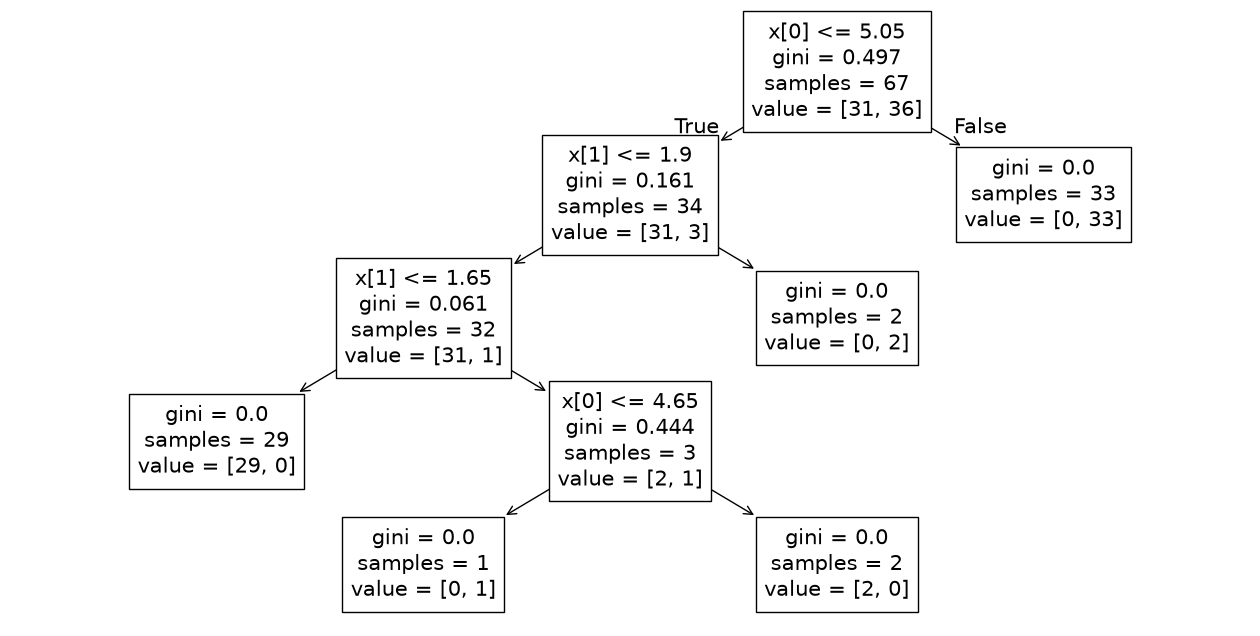

In [21]:
clf = tree.DecisionTreeClassifier(random_state=42)
clf.fit(X_train, Y_train)

fig, ax = plt.subplots(figsize=(16,8))
tree.plot_tree(clf)
plt.show()

In [35]:
atributo_usado = clf.tree_.feature[0]
limite_divisao = clf.tree_.threshold[0]
num_dados = clf.tree_.n_node_samples[0]
total_nos = clf.tree_.node_count

print('total de nos: ',total_nos)
print('Separou na variavel', atributo_usado, 'No valor', limite_divisao, 'num de dados usados nesse node', num_dados)

total de nos:  9
Separou na variavel 0 No valor 5.049999952316284 num de dados usados nesse node 67


In [40]:
# ve oq esses campos retornam para nós folhas
atributo_usado = clf.tree_.feature[5]
limite_divisao = clf.tree_.threshold[5]
num_dados = clf.tree_.n_node_samples[5]

print('Separou na variavel', atributo_usado, 'No valor', limite_divisao, 'num de dados usados nesse node', num_dados)

Separou na variavel -2 No valor -2.0 num de dados usados nesse node 1


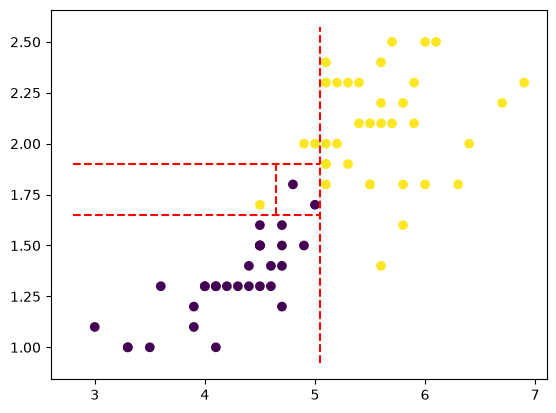

In [105]:
fig, ax = plt.subplots()
ax.scatter(X_train['petal length (cm)'], X_train['petal width (cm)'], c=Y_train)

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

horizontal_lim1 = horizontal_lim2 = y_min
vertical_lim1 = vertical_lim2 = x_min
for node_idx in range(clf.tree_.node_count):
    # ignora nos folha
    if(clf.tree_.feature[node_idx] < 0): continue
    horizontal_line = clf.tree_.feature[node_idx] == 1
    ponto_divisao = clf.tree_.threshold[node_idx]
    if(horizontal_line):
        if(vertical_lim1 == x_min and vertical_lim2 == x_min):
            min_val = x_min
            max_val = x_max
        else:
            min_val = min(vertical_lim1, vertical_lim2)
            max_val = max(vertical_lim1, vertical_lim2)
        plt.hlines(y=ponto_divisao, xmin=min_val, xmax=max_val, color='r', linestyle='--')
        horizontal_lim2 = horizontal_lim1
        horizontal_lim1 = ponto_divisao
    else:
        if(horizontal_lim1 == y_min and horizontal_lim2 == y_min):
            min_val = y_min
            max_val = y_max
        else:
            min_val = min(horizontal_lim1, horizontal_lim2)
            max_val = max(horizontal_lim1, horizontal_lim2)
        plt.vlines(x=ponto_divisao, ymin=min_val, ymax=max_val, color='r', linestyle='--')
        vertical_lim2 = vertical_lim1
        vertical_lim1 = ponto_divisao

plt.show()